### Importing libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv(r"D:\Study\Testing dataset\CSV data\IRIS.csv")

In [21]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [22]:
df.isnull()

,sepal_length,sepal_width,petal_length,petal_width,species
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [24]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [25]:
from sklearn.preprocessing import LabelEncoder

In [26]:
scaler = LabelEncoder()

In [27]:
df['species'] = scaler.fit_transform(df['species'])

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV

In [29]:
from sklearn.pipeline import Pipeline

In [30]:
from sklearn.neighbors import KNeighborsClassifier

### Spliting dataset into X, Y

In [31]:
X = df.iloc[:, 0:-1]
Y = df.iloc[:, -1]

In [32]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size= 0.4, train_size= 0.6, random_state= 42, shuffle=True)

### Setting up pipeline and perameter for hypertuning

In [33]:
pipe = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier())])

In [34]:
parameter = {'model__n_neighbors': [5, 10, 15, 20, 30, 40], 
             'model__weights':['uniform', 'distance'], 'model__leaf_size':[30, 40, 60],
            'model__p':[1, 2], 'model__algorithm' : ['auto', 'ball_tree', 'kd_tree', 'brute']}

In [35]:
from sklearn.metrics import classification_report

In [36]:
random = RandomizedSearchCV(pipe, param_distributions= parameter, n_iter = 20, n_jobs = -1, cv = 20, verbose= 2)

In [37]:
random.fit(x_train, y_train)

Fitting 20 folds for each of 20 candidates, totalling 400 fits


RandomizedSearchCV(cv=20,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('model',
                                              KNeighborsClassifier())]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__algorithm': ['auto',
                                                             'ball_tree',
                                                             'kd_tree',
                                                             'brute'],
                                        'model__leaf_size': [30, 40, 60],
                                        'model__n_neighbors': [5, 10, 15, 20,
                                                               30, 40],
                                        'model__p': [1, 2],
                                        'model__weights': ['uniform',
                                                           'distance']},
                   verbose=2)

In [38]:
random.score(x_test, y_test)

0.9833333333333333

In [39]:
pred = random.predict(x_test)

In [40]:
report = classification_report(y_test, pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.95      1.00      0.97        19
           2       1.00      0.94      0.97        18

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



### Visualize

In [41]:
from sklearn.metrics import accuracy_score, f1_score, con

In [42]:
cm = confusion_matrix(y_test, pred)
print(cm)

[[23  0  0]
 [ 0 19  0]
 [ 0  1 17]]


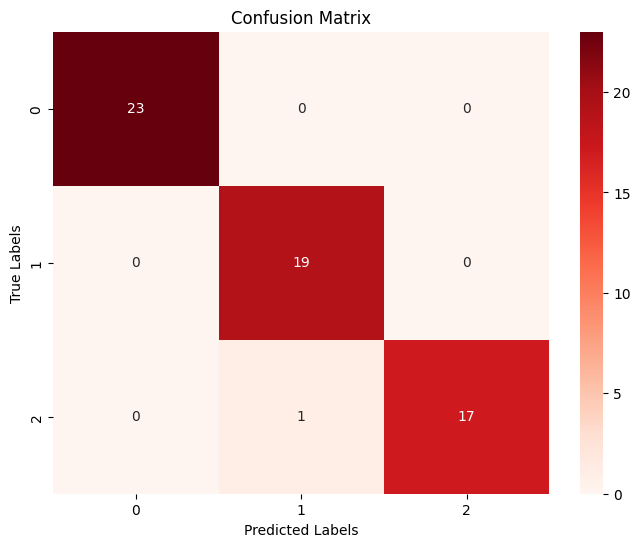

In [46]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

C:\Users\Shanta\AppData\Local\Temp\ipykernel_19992\996035119.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title = 'IRIS', labelcolor = 'red')
C:\Users\Shanta\AppData\Local\Temp\ipykernel_19992\996035119.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(x = df.species, y = df.sepal_length, ci= False, color = 'green', width=0.5, edgecolor = 'black')


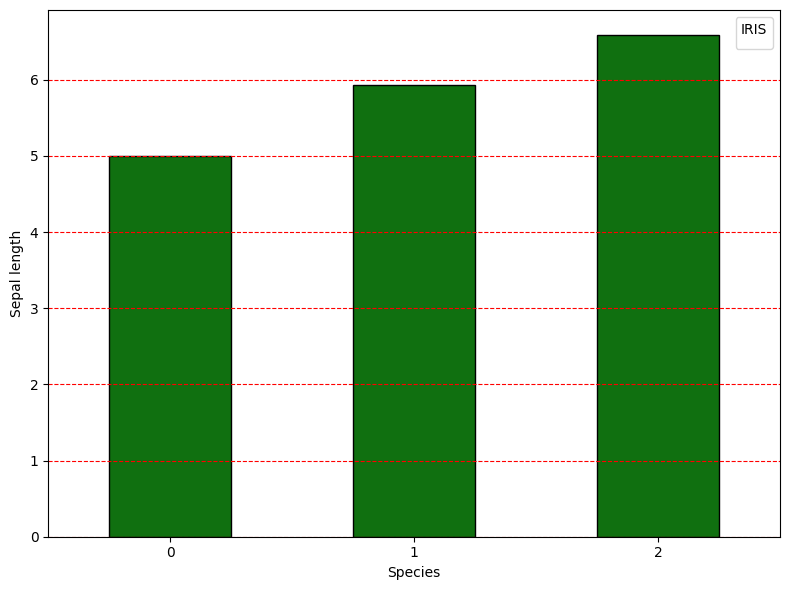

In [70]:
plt.figure(figsize = (8, 6), dpi = 100)
plt.xlabel('Species')
plt.ylabel('Sepal length')
plt.grid(linestyle = '--', alpha = 1, color='red')
plt.legend(title = 'IRIS', labelcolor = 'red')
sns.barplot(x = df.species, y = df.sepal_length, ci= False, color = 'green', width=0.5, edgecolor = 'black')
plt.tight_layout()
plt.show()